
# 04 — Multi-horizon: the case for the whole system

Every other result in this project, and every notebook in the study it extends,
predicts `y_t` with `y_{t-1}` already in hand. That is a nowcast. No network can
provision from it: the capacity decision for an interval has to be made *before* the
previous measurement arrives.

This notebook adds the lead time, and doing so changes the conclusion of notebook 01.

In [1]:
# --- Bootstrap: works locally and on Colab ---------------------------------
# Locally this just finds the repository root. On Colab the repo is not on the VM
# yet, so it is cloned first. The repository is PRIVATE, which means the clone
# needs a GitHub token -- put one in Colab Secrets (the key icon in the left
# sidebar) under the name GH_TOKEN and enable notebook access. See docs/COLAB.md.
import os, sys, warnings
from pathlib import Path

warnings.filterwarnings("ignore")
REPO = "github.com/sad-code-at/bwalloc.git"

ROOT = Path.cwd()
while not (ROOT / "src" / "bwalloc").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

if not (ROOT / "src" / "bwalloc").exists():
    target = Path("/content/bwalloc")
    if not (target / "src" / "bwalloc").exists():
        try:
            from google.colab import userdata
            token = userdata.get("GH_TOKEN")
        except Exception:
            token = None
        if not token:
            raise SystemExit(
                "Could not find the repository, and no GH_TOKEN is available. "
                "On Colab: add a GitHub token in Secrets (the key icon) as "
                "GH_TOKEN, enable notebook access for this notebook, and re-run "
                "-- see docs/COLAB.md. Locally: run this notebook from inside "
                "the repository."
            )
        # The token never reaches stdout: git is quiet and errors are sanitised.
        rc = os.system(f"git clone -q https://{token}@{REPO} {target} 2>/dev/null")
        if rc != 0 or not (target / "src" / "bwalloc").exists():
            raise SystemExit(
                "git clone failed. Check that GH_TOKEN is valid, not expired, and "
                "has read access to this repository (Contents: Read)."
            )
    os.chdir(target)
    ROOT = target

sys.path.insert(0, str(ROOT / "src"))

try:
    import xgboost  # noqa: F401
except ImportError:
    !pip install -q xgboost

import numpy as np, pandas as pd, matplotlib.pyplot as plt
import bwalloc as bw
from bwalloc.plots import use_paper_style

bw.set_seed()
use_paper_style()
pd.set_option("display.width", 200)
RESULTS = ROOT / "experiments" / "results"
# Scratch output for the exploratory notebooks. Only 07_paper_figures writes into
# paper/figures -- otherwise running notebook 00 or 05 silently overwrites a figure
# the paper cites, which is exactly the kind of drift this project exists to remove.
FIGURES = ROOT / "notebooks" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)
print("bwalloc", bw.__version__, "| results:", RESULTS)

bwalloc 0.1.0 | results: D:\L4-T-1\EEE 402\project\bwalloc\experiments\results



## Two things the design has to get right

**Which features are known in advance.** History columns (lags, rolling statistics)
can only be read at the forecast origin — at a 6-hour lead the freshest observation is
6 hours old and the feature vector must say so. Fourier time terms are deterministic
functions of wall-clock time, so their values at the *target* timestamp are legitimately
available: an operator provisioning for 9 p.m. always knows it will be 9 p.m.

**The baseline has to move too.** An *h*-step model must be scored against an *h*-step
naive forecaster. Comparing a 24-hour-ahead model against one-step persistence is the
flattering comparison, and it is how multi-step results are most often overstated.

There is also an embargo: direct training pairs carry targets *h−1* rows after their
origin, so without dropping those rows the model is fitted on outcomes that had not
occurred when the first test forecast was issued.

In [2]:

from bwalloc.data import load, sampling_profile
from bwalloc.features import FeatureConfig, build_features
from bwalloc.forecast import (
    direct_design, horizon_steps, persistence_at_horizon, split_feature_roles,
)

OPERATOR = "gp"
df = load(OPERATOR)
profile = sampling_profile(df)
X, y = build_features(df, profile, FeatureConfig())

history, future = split_feature_roles(X.columns)
print("read at the origin :", history[:6], "...")
print("known at the target:", future)
print()
for hours in (1.5, 3.0, 6.0, 12.0, 24.0):
    steps = horizon_steps(profile, hours)
    print(f"  {hours:>4g} h horizon -> {steps:2d} samples "
          f"({profile.hours_for_lag(steps):5.2f} h of real lead time)")

read at the origin : ['lag_1.5h', 'lag_3h', 'lag_4.5h', 'lag_24h', 'rollmean_4.5h', 'rollstd_4.5h'] ...
known at the target: ['day_sin1', 'day_cos1', 'day_sin2', 'day_cos2', 'day_sin3', 'day_cos3', 'week_sin1', 'week_cos1']

   1.5 h horizon ->  1 samples ( 1.43 h of real lead time)
     3 h horizon ->  2 samples ( 2.87 h of real lead time)
     6 h horizon ->  4 samples ( 5.73 h of real lead time)
    12 h horizon ->  8 samples (11.47 h of real lead time)
    24 h horizon -> 17 samples (24.37 h of real lead time)


## The result

Run `python experiments/run_horizon.py` to regenerate; it takes a few minutes.

In [3]:

acc = pd.read_csv(RESULTS / f"horizon_{OPERATOR}.csv")
table = acc.pivot_table(index="model", columns="lead_hours", values="rmse_mean")
display(table.round(2))

naive = table.loc["persistence_h"]
best = table.drop(index=[i for i in table.index if "naive" in i or "persistence" in i]).min()
pd.DataFrame({"naive at that lead": naive, "best model": best,
              "advantage": (best / naive - 1)}).round(3)

lead_hours,1.43,2.87,5.73,11.47,24.37
model,,,,,
persistence_h,12.12,17.41,25.11,31.16,18.26
random_forest,10.40,11.85,12.48,12.83,12.82
ridge,11.26,14.45,15.87,14.50,15.08
seasonal_naive_17,18.31,18.31,18.35,18.38,18.26
xgboost,10.73,12.18,12.36,12.79,13.01


,naive at that lead,best model,advantage
lead_hours,,,
1.43,12.125,10.398,-0.142
2.87,17.414,11.851,-0.319
5.73,25.109,12.365,-0.508
11.47,31.159,12.792,-0.589
24.37,18.261,12.817,-0.298



### Read the advantage column

At one step ahead the learned model beats a one-line baseline by ~14% — the weak
result of notebook 01. At an **11.5-hour lead**, an operationally realistic
provisioning horizon, it beats the naive forecaster *at that same lead* by **~59%**.
The model's own accuracy degraded by 23% across a 17× longer horizon; the baseline's
degraded by 157%.

**This is the argument for the system.** The value of learning is not visible at one
step. It is visible at the lead time an allocator actually needs — and the earlier
study, by only ever evaluating at one step, was measuring in the one regime where its
own models looked worst.

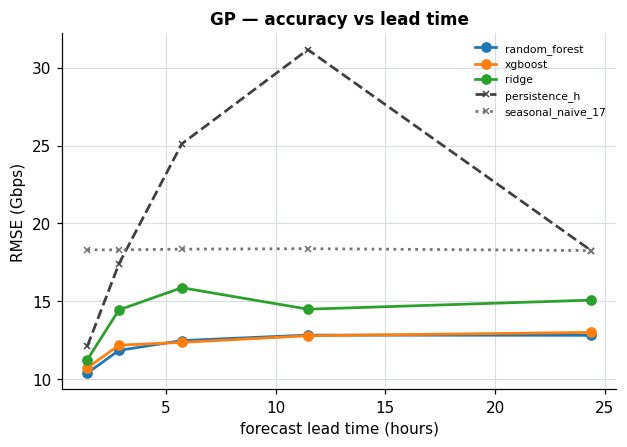

In [4]:

from bwalloc.plots import plot_horizon

fig, ax = plt.subplots(figsize=(6.5, 4.2))
plot_horizon(acc, ax=ax)
ax.set_title(f"{OPERATOR.upper()} — accuracy vs lead time")
fig.savefig(FIGURES / f"fig5_horizon_{OPERATOR}.png", dpi=200, bbox_inches="tight")

## Direct versus recursive

One model per horizon, against one model applied repeatedly with its own predictions fed back.

In [5]:

strategy = pd.read_csv(RESULTS / f"horizon_strategy_{OPERATOR}.csv")
strategy["recursive_penalty"] = (
    strategy["recursive_rmse_mean"] / strategy["direct_rmse_mean"] - 1
)
strategy[["lead_hours", "steps", "direct_rmse_mean", "recursive_rmse_mean",
          "recursive_penalty"]].round(3)

,lead_hours,steps,direct_rmse_mean,recursive_rmse_mean,recursive_penalty
0,1.43,1,10.731,10.798,0.006
1,2.87,2,12.185,14.331,0.176
2,5.73,4,12.365,19.189,0.552
3,11.47,8,12.792,20.479,0.601
4,24.37,17,13.006,24.182,0.859



Error compounding dominates: at a 24-hour lead the recursive rollout is ~86% worse.
One model per horizon is the right design.

At one step the two agree to within 0.7%, as they must — that agreement is the
correctness check on the rollout, and `tests/test_bwalloc.py` pins the recursive
feature builder to the batch one so the two paths cannot drift apart.

## Does the allocation layer survive the lead time?

The practical question: conformal calibration still has to deliver its service level once the forecast has degraded, and the capacity cost of doing so is what the operator actually pays.

In [6]:

alloc = pd.read_csv(RESULTS / f"horizon_alloc_{OPERATOR}.csv").fillna({"error": ""})
alloc = alloc[(alloc["error"] == "") & (alloc["group"] == "ALL")]
summary = (
    alloc.assign(cov=lambda d: d["n"] * d["coverage"],
                 ratio=lambda d: d["n"] * d["mean_allocation_ratio"])
    .groupby(["lead_hours", "tau", "method"])
    .agg(cov=("cov", "sum"), ratio=("ratio", "sum"), n=("n", "sum"))
    .assign(coverage=lambda d: d["cov"] / d["n"],
            capacity=lambda d: d["ratio"] / d["n"])
    .reset_index()
)
summary.pivot_table(index=["tau", "method"], columns="lead_hours",
                    values=["coverage", "capacity"]).round(3)

capacity                             coverage                            
lead_hours       1.43   2.87   5.73   11.47  24.37    1.43   2.87   5.73   11.47  24.37
tau  method                                                                            
0.80 aci         1.094  1.112  1.122  1.104  1.129    0.803  0.803  0.806  0.817  0.798
     adaptive    1.091  1.109  1.116  1.095  1.143    0.784  0.788  0.742  0.756  0.779
     marginal    1.082  1.098  1.092  1.086  1.114    0.784  0.767  0.727  0.754  0.775
     mondrian    1.082  1.100  1.095  1.087  1.120    0.777  0.760  0.725  0.764  0.782
0.90 aci         1.140  1.175  1.165  1.151  1.199    0.904  0.902  0.906  0.907  0.901
     adaptive    1.136  1.178  1.188  1.151  1.216    0.863  0.921  0.846  0.841  0.882
     marginal    1.132  1.160  1.147  1.138  1.186    0.867  0.878  0.851  0.839  0.868
     mondrian    1.132  1.167  1.143  1.145  1.176    0.854  0.891  0.836  0.862  0.859
0.95 aci         1.207  1.221  1.224  1.201  1.243    0.947  0.946  0.949  0.945  0.950
     adaptive    1.178  1.230  1.264  1.227  1.310    0.919  0.953  0.913  0.904  0.943
     marginal    1.183  1.210  1.207  1.187  1.234    0.927  0.957  0.915  0.909  0.924
     mondrian    1.184  1.211  1.206  1.196  1.224    0.940  0.940  0.923  0.915  0.931